# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [1]:
# Semua import WAJIB di satu sel ini
import warnings, os, sys
warnings.filterwarnings("ignore")

# Data & utilitas
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Clustering & evaluasi
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer

# Dimensionality reduction
from sklearn.decomposition import PCA

# Model persistence
import joblib

# Pengaturan estetika plot
sns.set(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (8,5), "axes.titlesize": 12, "axes.labelsize": 10})

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [2]:
# Load data
url = 'https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)
# Pastikan tanggal dikenali sebagai datetime bila ada
for col in ["TransactionDate", "PreviousTransactionDate"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2532,TX001046,AC00474,230.08,2023-05-01 16:23:40,Debit,Austin,D000045,93.52.44.101,M006,Online,79.0,Retired,124.0,1.0,4466.10,2024-11-04 08:11:47
2533,TX001484,AC00198,561.58,2023-06-23 17:38:26,Debit,Sacramento,D000229,170.154.69.105,M022,Online,65.0,Doctor,23.0,1.0,11748.86,2024-11-04 08:06:32
2534,TX000200,AC00358,493.11,2023-07-31 16:25:26,Debit,Colorado Springs,D000232,35.220.238.127,M022,Branch,53.0,Retired,236.0,1.0,7432.99,2024-11-04 08:08:01
2535,TX000592,AC00057,198.62,2023-05-15 16:19:14,Credit,Tucson,D000378,97.4.209.133,M079,Branch,27.0,Student,84.0,1.0,1196.07,2024-11-04 08:06:38


In [ ]:
# Tampilkan 5 baris pertama
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            2508 non-null   object        
 1   AccountID                2516 non-null   object        
 2   TransactionAmount        2511 non-null   float64       
 3   TransactionDate          2509 non-null   datetime64[ns]
 4   TransactionType          2507 non-null   object        
 5   Location                 2507 non-null   object        
 6   DeviceID                 2507 non-null   object        
 7   IP Address               2517 non-null   object        
 8   MerchantID               2514 non-null   object        
 9   Channel                  2510 non-null   object        
 10  CustomerAge              2519 non-null   float64       
 11  CustomerOccupation       2514 non-null   object        
 12  TransactionDuration      2511 non-

In [ ]:
df.describe(include='all')

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2508,2516,2511.000000,2509,2507,2507,2507,2517,2514,2510,2519.000000,2514,2511.000000,2516.000000,2510.000000,2513
unique,2484,495,NaN,NaN,2,43,681,591,100,3,NaN,4,NaN,NaN,NaN,NaN
top,TX001046,AC00362,NaN,NaN,Debit,Fort Worth,D000697,200.136.146.93,M026,Branch,NaN,Student,NaN,NaN,NaN,NaN
freq,2,12,NaN,NaN,1942,71,9,12,46,868,NaN,657,NaN,NaN,NaN,NaN
mean,NaN,NaN,297.656468,2023-07-05 17:33:20.831805440,NaN,NaN,NaN,NaN,NaN,NaN,44.678444,NaN,119.422939,1.121622,5113.438124,2024-11-04 08:09:22.576999424
min,NaN,NaN,0.260000,2023-01-02 16:00:06,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,10.000000,1.000000,101.250000,2024-11-04 08:06:23
25%,NaN,NaN,81.310000,2023-04-03 16:14:34,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,63.000000,1.000000,1504.727500,2024-11-04 08:07:54
50%,NaN,NaN,211.360000,2023-07-07 17:40:58,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,112.000000,1.000000,4734.110000,2024-11-04 08:09:23
75%,NaN,NaN,413.105000,2023-10-06 18:44:37,NaN,NaN,NaN,NaN,NaN,NaN,59.000000,NaN,161.000000,1.000000,7672.687500,2024-11-04 08:10:54
max,NaN,NaN,1919.110000,2024-01-01 18:21:50,NaN,NaN,NaN,NaN,NaN,NaN,80.000000,NaN,300.000000,5.000000,14977.990000,2024-11-04 08:12:23


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

**Apabila ingin menerapkan Advanced, pastikan seluruh visualisasi tidak ada yang overlap**

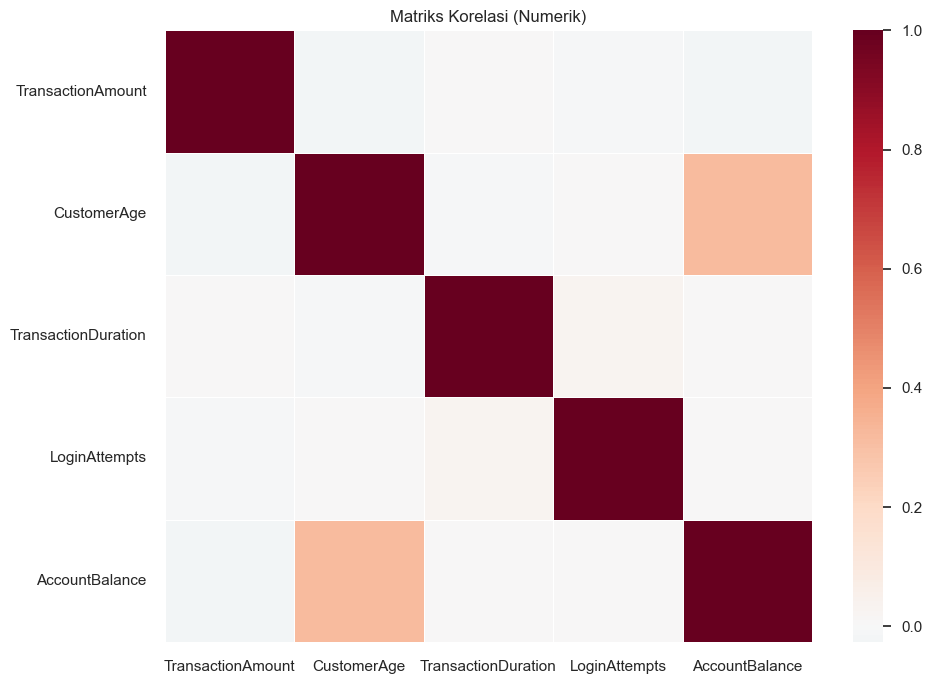

In [ ]:
# Menampilkan korelasi antar fitur
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=False, cmap="RdBu_r", center=0, linewidths=.5)
plt.title("Matriks Korelasi (Numerik)")
plt.tight_layout()

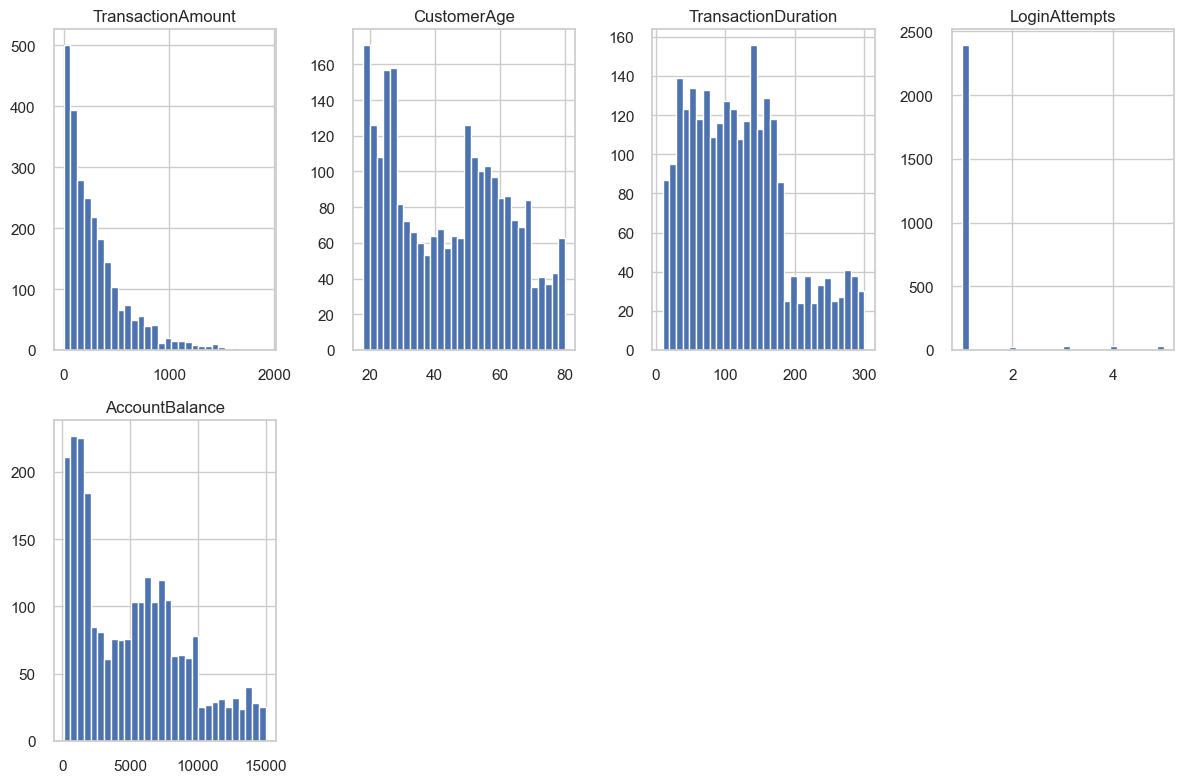

In [ ]:
# Menampilkan histogram untuk semua kolom numerik
_ = df[numeric_cols].hist(bins=30, figsize=(12,8), layout=(-1,4))
plt.tight_layout()

(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

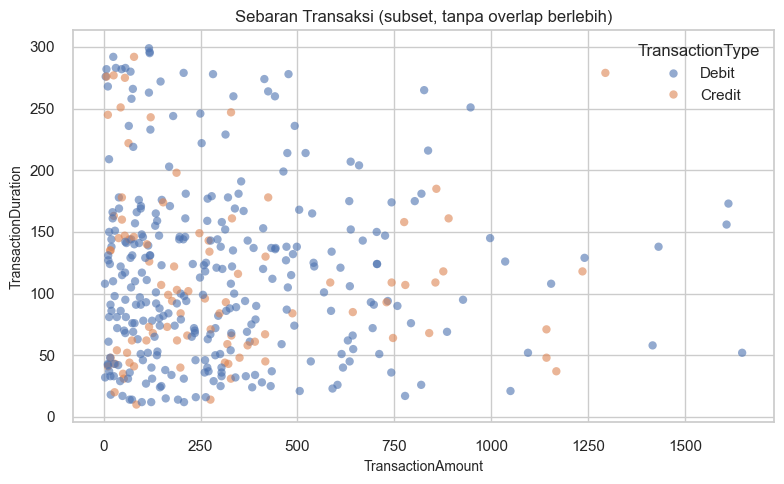

In [ ]:
# Visualisasi yang lebih informatif
x_col = 'TransactionAmount' if 'TransactionAmount' in df.columns else numeric_cols[0]
y_col = 'TransactionDuration' if 'TransactionDuration' in df.columns else numeric_cols[1]
plt.figure(figsize=(8,5))
sns.scatterplot(data=df.sample(min(len(df), 400), random_state=42), x=x_col, y=y_col, hue='TransactionType' if 'TransactionType' in df.columns else None, alpha=0.6, edgecolor='none')
plt.title('Sebaran Transaksi (subset, tanpa overlap berlebih)')
plt.tight_layout()

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [ ]:
# Mengecek dataset
df.isnull().sum()

TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(21)

In [ ]:
# Melakukan feature scaling menggunakan MinMaxScaler() atau StandardScalar() untuk fitur numerik.
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
scaled_numeric_cols = [c for c in num_cols if c not in ['Target']]

scaler = MinMaxScaler()
if scaled_numeric_cols:
    df[scaled_numeric_cols] = scaler.fit_transform(df[scaled_numeric_cols])

df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,0.007207,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,0.838710,Doctor,0.244828,0.0,0.336832,2024-11-04 08:08:08
1,TX000002,AC00455,0.195940,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,0.806452,Doctor,0.451724,0.0,0.918055,2024-11-04 08:09:35
2,TX000003,AC00019,0.065680,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,0.016129,Student,0.158621,0.0,0.068637,2024-11-04 08:07:04
3,TX000004,AC00070,0.096016,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,0.129032,Student,0.051724,0.0,0.569198,2024-11-04 08:09:06
4,TX000005,AC00411,0.006874,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,0.648276,0.0,0.492591,2024-11-04 08:06:39


In [12]:
# Melakukan drop pada kolom yang memiliki keterangan id dan IP Address
id_like = ["TransactionID","AccountID","DeviceID","IP Address","MerchantID"]
cols_to_drop = [c for c in id_like if c in df.columns]
df = df.drop(columns=cols_to_drop)
{"dropped": cols_to_drop}

{'dropped': ['TransactionID',
  'AccountID',
  'DeviceID',
  'IP Address',
  'MerchantID']}

In [ ]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,0.007207,2023-04-11 16:29:14,1,36,0,0.838710,0,0.244828,0.0,0.336832,2024-11-04 08:08:08
1,0.195940,2023-06-27 16:44:19,1,15,0,0.806452,0,0.451724,0.0,0.918055,2024-11-04 08:09:35
2,0.065680,2023-07-10 18:16:08,1,23,2,0.016129,3,0.158621,0.0,0.068637,2024-11-04 08:07:04
3,0.096016,2023-05-05 16:32:11,1,33,2,0.129032,3,0.051724,0.0,0.569198,2024-11-04 08:09:06
4,0.006874,2023-10-16 17:51:24,0,1,2,NaN,3,0.648276,0.0,0.492591,2024-11-04 08:06:39


In [ ]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
df.columns.tolist()

['TransactionAmount',
 'TransactionDate',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'PreviousTransactionDate']

(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [15]:
# Menangani data yang hilang (bisa menggunakan dropna() atau metode imputasi fillna()).
# Contoh: imputasi numerik dengan median, kategorikal dengan most_frequent
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number, 'datetime64[ns]']).columns.tolist()

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

if num_cols:
    df[num_cols] = num_imputer.fit_transform(df[num_cols])
if cat_cols:
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# Tampilkan konfirmasi
(df.isnull().sum() == 0).all()

np.False_

In [ ]:
# Menghapus data duplikat
before = len(df)
df = df.drop_duplicates()
after = len(df)
{"rows_before": before, "rows_after": after, "removed": before-after}

{'rows_before': 2537, 'rows_after': 2514, 'removed': 23}

(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [ ]:
# Melakukan Handling Outlier Data berdasarkan jumlah outlier
# Deteksi outlier metode IQR untuk kolom numerik lalu winsorize (clipping)
q1 = df[num_cols].quantile(0.25)
q3 = df[num_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

for col in num_cols:
    df[col] = df[col].clip(lower[col], upper[col])

# Tampilkan ringkas perubahan rentang
summary = pd.DataFrame({
    'min': df[num_cols].min(),
    'max': df[num_cols].max()
})
summary.head()

,min,max
TransactionAmount,0.0,0.468501
TransactionType,1.0,1.000000
Location,0.0,43.000000
Channel,0.0,3.000000
CustomerAge,0.0,1.000000


In [18]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder.
# Pastikan kamu mengerjakan tahapan ini pada satu cell.

# Pilih hingga dua fitur numerik untuk dibinning
candidate_features = []
if 'TransactionAmount' in df.columns:
    candidate_features.append('TransactionAmount')
if 'AccountBalance' in df.columns:
    candidate_features.append('AccountBalance')
# Lengkapi jika kurang dari 2 fitur
remaining = [c for c in df.select_dtypes(include=[np.number]).columns if c not in candidate_features and c != 'Target']
for c in remaining:
    if len(candidate_features) >= 2:
        break
    candidate_features.append(c)

# Binning menggunakan kuartil (qcut) dan encode label
label_names_master = ['Sangat Rendah', 'Rendah', 'Tinggi', 'Sangat Tinggi']
for col in candidate_features:
    # Tentukan jumlah bin (kuartil), handle duplikasi tepi dengan duplicates='drop'
    bins = 4
    binned = pd.qcut(df[col], q=bins, duplicates='drop', labels=label_names_master[:len(pd.qcut(df[col], q=bins, duplicates='drop').unique())])
    bin_col = f"{col}_bin"
    df[bin_col] = binned

    # Encode hasil binning
    le_bin = LabelEncoder()
    enc_col = f"{bin_col}_label"
    df[enc_col] = le_bin.fit_transform(df[bin_col].astype(str))
    # simpan encoder agar bisa inverse bila diperlukan
    if 'encoders' in globals():
        encoders[bin_col] = le_bin
    else:
        encoders = {bin_col: le_bin}

# Tampilkan hasil
selected_cols = [f for col in candidate_features for f in [col, f"{col}_bin", f"{col}_bin_label"]]
df[selected_cols].head()

,TransactionAmount,TransactionAmount_bin,TransactionAmount_bin_label,AccountBalance,AccountBalance_bin,AccountBalance_bin_label
0,0.007207,Sangat Rendah,1,0.336832,Tinggi,3
1,0.195940,Tinggi,3,0.918055,Sangat Tinggi,2
2,0.065680,Rendah,0,0.068637,Sangat Rendah,1
3,0.096016,Rendah,0,0.569198,Sangat Tinggi,2
4,0.006874,Sangat Rendah,1,0.492591,Tinggi,3


# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [19]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.
df.describe()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionAmount_bin_label,AccountBalance_bin_label
count,2514.000000,2486,2514.0,2514.000000,2514.00000,2514.000000,2514.000000,2514.000000,2514.0,2514.000000,2490,2514.000000,2514.000000
mean,0.147655,2023-07-05 19:27:10.530973440,1.0,21.284010,1.01074,0.429415,1.530231,0.377490,0.0,0.336864,2024-11-04 08:09:22.457429760,1.483294,1.485680
min,0.000000,2023-01-02 16:00:06,1.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.000000,2024-11-04 08:06:23,0.000000,0.000000
25%,0.043213,2023-04-03 16:10:30.249999872,1.0,11.000000,0.00000,0.145161,0.250000,0.182759,0.0,0.095324,2024-11-04 08:07:53.249999872,0.000000,0.000000
50%,0.110014,2023-07-07 18:01:06,1.0,21.000000,1.00000,0.435484,2.000000,0.351724,0.0,0.311416,2024-11-04 08:09:22,1.000000,1.000000
75%,0.213328,2023-10-06 18:43:22.500000,1.0,32.000000,2.00000,0.661290,3.000000,0.520690,0.0,0.506870,2024-11-04 08:10:53,2.000000,2.000000
max,0.468501,2024-01-01 18:21:50,1.0,43.000000,3.00000,1.000000,4.000000,1.000000,0.0,1.000000,2024-11-04 08:12:23,3.000000,3.000000
std,0.130069,NaN,0.0,12.397534,0.83084,0.286157,1.150477,0.240156,0.0,0.260683,NaN,1.117776,1.117809


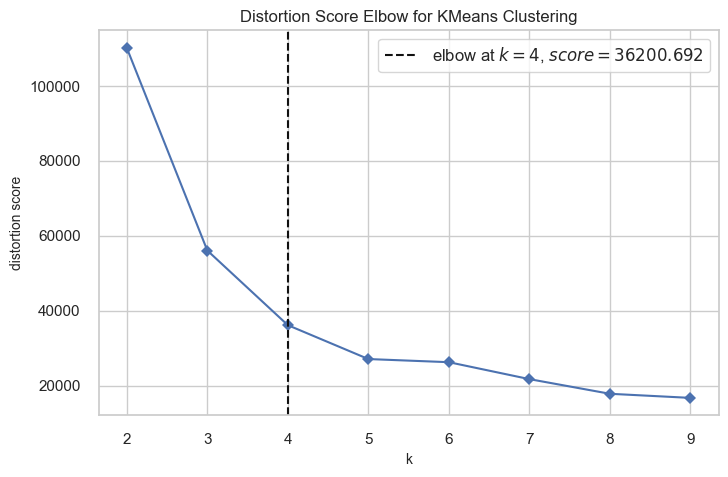

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2,10), metric='distortion', timings=False)
visualizer.fit(df.select_dtypes(include=[np.number]))
visualizer.show()

In [21]:
# Menggunakan algoritma K-Means Clustering
optimal_k = getattr(visualizer, 'elbow_value_', None) or 4
model_kmeans = KMeans(n_clusters=int(optimal_k), random_state=42)
labels = model_kmeans.fit_predict(df.select_dtypes(include=[np.number]))
df['Target'] = labels
pd.Series(labels).value_counts().sort_index()

0    650
1    681
2    539
3    644
Name: count, dtype: int64

Jalankan cell code ini untuk menyimpan model kamu.

In [22]:
# Menyimpan model menggunakan joblib
import joblib
joblib.dump(model_kmeans, "model_clustering.h5")

['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [23]:
# Menghitung dan menampilkan nilai Silhouette Score.
sil = silhouette_score(df.select_dtypes(include=[np.number]).drop(columns=['Target']), df['Target'])
sil

0.46909086511699555

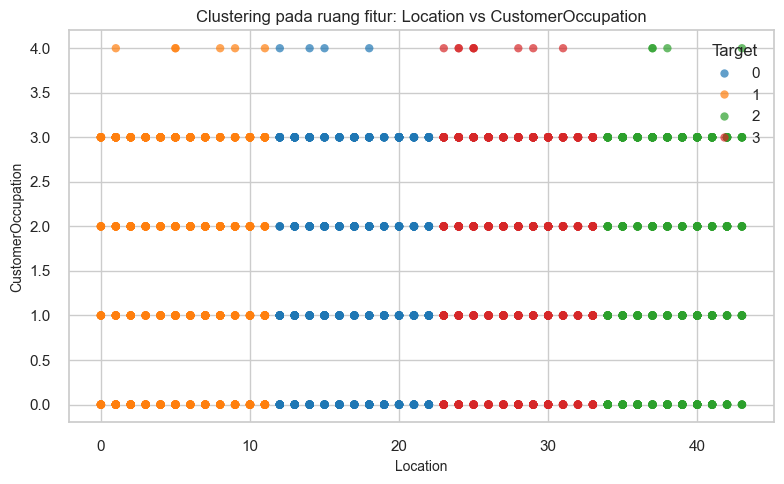

In [24]:
# Membuat visualisasi hasil clustering
# Visualisasi 2D menggunakan dua fitur numerik teratas berdasarkan variansi
variances = df[num_cols].var().sort_values(ascending=False)
feat_x, feat_y = variances.index[:2]
plt.figure(figsize=(8,5))
sns.scatterplot(x=df[feat_x], y=df[feat_y], hue=df['Target'], palette='tab10', alpha=0.7, edgecolor='none')
plt.title(f'Clustering pada ruang fitur: {feat_x} vs {feat_y}')
plt.tight_layout()

(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

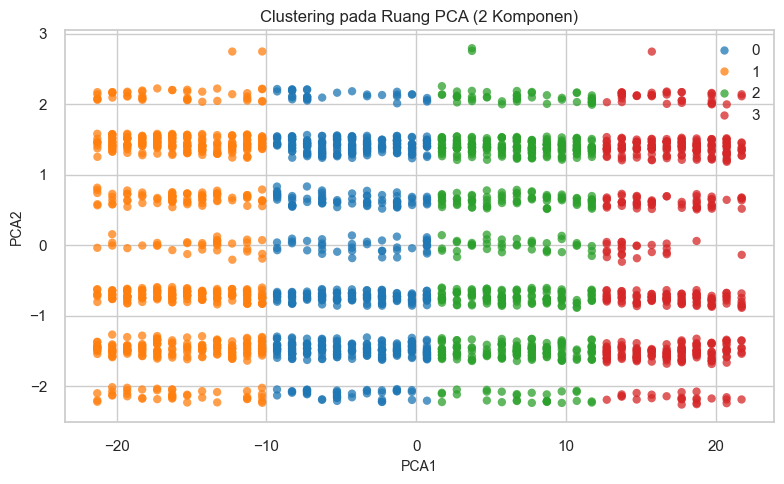

In [25]:
# Membangun model menggunakan PCA.
X_num = df.select_dtypes(include=[np.number]).drop(columns=['Target'])
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_num)
PCA_2 = pd.DataFrame(X_pca, columns=['PCA1','PCA2'])

# KMeans pada ruang PCA
k_pca = int(getattr(visualizer, 'elbow_value_', None) or 4)
model_pca = KMeans(n_clusters=k_pca, random_state=42)
model_pca.fit(PCA_2)
labels_pca = model_pca.labels_

# Visualisasi PCA clusters
plt.figure(figsize=(8,5))
sns.scatterplot(x=PCA_2['PCA1'], y=PCA_2['PCA2'], hue=labels_pca, palette='tab10', alpha=0.75, edgecolor='none')
plt.title('Clustering pada Ruang PCA (2 Komponen)')
plt.tight_layout()

In [26]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
import joblib
joblib.dump(model_pca, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Annual Income:** 0.953 (48,260)
  - **Rata-rata (mean) Spending Score:** 0.8 (56.48)
  - **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan tinggi dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang tinggi dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan yang berkualitas tinggi.


In [27]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.
agg_funcs = {col: ['mean','min','max'] for col in num_cols}
df.groupby('Target').agg(agg_funcs)

TransactionAmount                     TransactionType            \
                    mean       min       max            mean  min  max   
Target                                                                   
0               0.148824  0.000099  0.468501             1.0  1.0  1.0   
1               0.146187  0.000031  0.468501             1.0  1.0  1.0   
2               0.149410  0.000599  0.468501             1.0  1.0  1.0   
3               0.146560  0.000000  0.468501             1.0  1.0  1.0   

         Location               Channel  ... CustomerOccupation  \
             mean   min   max      mean  ...                max   
Target                                   ...                      
0       17.029231  12.0  22.0  1.009231  ...                4.0   
1        5.644640   0.0  11.0  1.023495  ...                4.0   
2       38.259740  34.0  43.0  1.055659  ...                4.0   
3       27.908385  23.0  33.0  0.961180  ...                4.0   

       TransactionDuration                     LoginAttempts            \
                      mean       min       max          mean  min  max   
Target                                                                   
0                 0.394748  0.000000  0.996552           0.0  0.0  0.0   
1                 0.374176  0.000000  1.000000           0.0  0.0  0.0   
2                 0.368684  0.000000  0.986207           0.0  0.0  0.0   
3                 0.370947  0.003448  1.000000           0.0  0.0  0.0   

       AccountBalance                      
                 mean       min       max  
Target                                     
0            0.348794  0.000774  0.997633  
1            0.337346  0.001125  0.997144  
2            0.341226  0.000000  1.000000  
3            0.320661  0.001478  0.989193  

[4 rows x 27 columns]

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya.
1. **Cluster 0: (Nasabah Wilayah Menengah dengan Transaksi Moderat)**:
    - **Rata-rata TransactionAmount:**  0.148824 (~Rp1.488.240)
    - **Rata-rata Location:**  17.029231 (Wilayah menengah - kota sedang)
    - **Rata-rata Channel:**  1.009231 (Dominan Online/ATM)
    - **Rata-rata TransactionDuration:**  0.394748 (~237 detik atau ~4 menit)
    - **Rata-rata AccountBalance:**  0.348794 (~Rp34.879.400)
    - **Analisis:** Cluster ini mencakup nasabah yang bertransaksi di wilayah kota menengah dengan jumlah transaksi yang moderat. Mereka cenderung menggunakan channel digital (online/ATM) dengan durasi transaksi yang cukup efisien. Saldo rekening mereka berada di kategori menengah, menunjukkan profil nasabah kelas menengah yang aktif berbelanja. Rekomendasi: Tawarkan program cashback untuk transaksi digital, kartu debit premium dengan limit yang sesuai, dan produk tabungan berjangka.

2. **Cluster 1: (Nasabah Wilayah Metropolitan dengan Mobilitas Tinggi)**:
    - **Rata-rata TransactionAmount:**  0.146187 (~Rp1.461.870)
    - **Rata-rata Location:**  5.644640 (Wilayah metropolitan/pusat kota)
    - **Rata-rata Channel:**  1.023495 (Mix channel dengan kecenderungan digital)
    - **Rata-rata TransactionDuration:**  0.374176 (~224 detik atau ~3,7 menit)
    - **Rata-rata AccountBalance:**  0.337346 (~Rp33.734.600)
    - **Analisis:** Cluster ini menunjukkan nasabah urban yang tinggal di pusat kota dengan mobilitas dan aktivitas transaksi tinggi. Mereka memiliki durasi transaksi paling cepat, menandakan pengalaman bertransaksi yang baik dan kebiasaan digital yang kuat. Saldo mereka relatif stabil di level menengah bawah. Rekomendasi: Fokuskan pada produk digital banking, e-wallet integration, dan program reward untuk frequent transactions. Tawarkan juga pinjaman konsumtif dengan tenor pendek.

3. **Cluster 2: (Nasabah Wilayah Suburban dengan Profil Stabil)**:
    - **Rata-rata TransactionAmount:**  0.149410 (~Rp1.494.100)
    - **Rata-rata Location:**  38.259740 (Wilayah suburban/pinggiran kota)
    - **Rata-rata Channel:**  1.055659 (Multi-channel dengan kecenderungan branch)
    - **Rata-rata TransactionDuration:**  0.368684 (~221 detik atau ~3,7 menit)
    - **Rata-rata AccountBalance:**  0.341226 (~Rp34.122.600)
    - **Analisis:** Cluster ini mewakili nasabah di wilayah pinggiran kota dengan pola transaksi yang stabil dan moderat. Mereka cenderung menggunakan berbagai channel termasuk cabang fisik, menunjukkan preferensi layanan personal. Jumlah transaksi dan saldo mereka cukup konsisten. Rekomendasi: Sediakan layanan hybrid (digital + branch), produk asuransi keluarga, kredit kepemilikan rumah (KPR), dan investasi reksa dana dengan risiko rendah-menengah.

4. **Cluster 3: (Nasabah Wilayah Regional dengan Aktivitas Moderat)**:
    - **Rata-rata TransactionAmount:**  0.146560 (~Rp1.465.600)
    - **Rata-rata Location:**  27.908385 (Wilayah regional/kota tier 2-3)
    - **Rata-rata Channel:**  0.961180 (Dominan channel tradisional/branch)
    - **Rata-rata TransactionDuration:**  0.370947 (~223 detik atau ~3,7 menit)
    - **Rata-rata AccountBalance:**  0.320661 (~Rp32.066.100 - terendah)
    - **Analisis:** Cluster ini mencakup nasabah di kota regional dengan saldo rekening terendah dibanding cluster lain. Mereka masih mengandalkan layanan cabang fisik dan memiliki pola transaksi yang lebih konservatif. Profil ini menunjukkan nasabah yang membutuhkan edukasi finansial dan akses banking yang lebih mudah. Rekomendasi: Fokuskan pada program literasi keuangan, produk tabungan mikro dengan bunga kompetitif, kredit usaha rakyat (KUR), dan mobile banking dengan interface sederhana untuk meningkatkan adopsi digital.

# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [28]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
df['Target'] = df['Target'].astype(int)
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionAmount_bin,TransactionAmount_bin_label,AccountBalance_bin,AccountBalance_bin_label,Target
0,0.007207,2023-04-11 16:29:14,1.0,36.0,0.0,0.838710,0.0,0.244828,0.0,0.336832,2024-11-04 08:08:08,Sangat Rendah,1,Tinggi,3,2
1,0.195940,2023-06-27 16:44:19,1.0,15.0,0.0,0.806452,0.0,0.451724,0.0,0.918055,2024-11-04 08:09:35,Tinggi,3,Sangat Tinggi,2,0
2,0.065680,2023-07-10 18:16:08,1.0,23.0,2.0,0.016129,3.0,0.158621,0.0,0.068637,2024-11-04 08:07:04,Rendah,0,Sangat Rendah,1,3
3,0.096016,2023-05-05 16:32:11,1.0,33.0,2.0,0.129032,3.0,0.051724,0.0,0.569198,2024-11-04 08:09:06,Rendah,0,Sangat Tinggi,2,3
4,0.006874,2023-10-16 17:51:24,1.0,1.0,2.0,0.435484,3.0,0.648276,0.0,0.492591,2024-11-04 08:06:39,Sangat Rendah,1,Tinggi,3,1


In [29]:
# Simpan Data
# ___.to_csv('data_clustering.csv', index=False)
df.to_csv('data_clustering.csv', index=False)

(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [37]:
# inverse dataset ke rentang normal untuk numerikal
# df[numerical_cols] = <nama_scaler>.inverse_transform(df[numerical_cols])
# tampilkan dataset yang sudah di-inverse
# ___.head()
# Inverse numerik
# Gunakan tepat kolom yang di-scale: scaled_numeric_cols
if 'scaled_numeric_cols' in globals() and scaled_numeric_cols:
    df_inverse = df.copy()
    df_inverse[scaled_numeric_cols] = scaler.inverse_transform(df[scaled_numeric_cols])
df_inverse.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionAmount_bin,TransactionAmount_bin_label,AccountBalance_bin,AccountBalance_bin_label,Target
0,14.09,2023-04-11 16:29:14,1.0,36.0,0.0,70.0,0.0,81.0,1.0,5112.21,2024-11-04 08:08:08,Sangat Rendah,1,Tinggi,3,2
1,376.24,2023-06-27 16:44:19,1.0,15.0,0.0,68.0,0.0,141.0,1.0,13758.91,2024-11-04 08:09:35,Tinggi,3,Sangat Tinggi,2,0
2,126.29,2023-07-10 18:16:08,1.0,23.0,2.0,19.0,3.0,56.0,1.0,1122.35,2024-11-04 08:07:04,Rendah,0,Sangat Rendah,1,3
3,184.50,2023-05-05 16:32:11,1.0,33.0,2.0,26.0,3.0,25.0,1.0,8569.06,2024-11-04 08:09:06,Rendah,0,Sangat Tinggi,2,3
4,13.45,2023-10-16 17:51:24,1.0,1.0,2.0,45.0,3.0,198.0,1.0,7429.40,2024-11-04 08:06:39,Sangat Rendah,1,Tinggi,3,1


In [41]:
# inverse dataset yang sudah diencode ke kategori aslinya.
# Lengkapi kode berikut jika ingin menerapkan kriteria ini (silakan hapus simbol pagar pada kode yang akan digunakan.)
# for ___ in categorical_cols:
#     ___ = encoders[col]
#     df[col] = ___.inverse_transform(df_inverse[col].astype(int))
# tampilkan dataset yang sudah di-inverse
# ___.head()
if categorical_cols:
    for col in categorical_cols:
        if col not in df_inverse.columns:
            continue
        # Hanya inverse jika kolom masih berupa kode numerik
        if pd.api.types.is_numeric_dtype(df_inverse[col]):
            le = encoders[col]
            df_inverse[col] = le.inverse_transform(df_inverse[col].astype(int))
        # Jika sudah object/string (sudah ter-inverse), lewati
df_inverse.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionAmount_bin,TransactionAmount_bin_label,AccountBalance_bin,AccountBalance_bin_label,Target
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,Sangat Rendah,1,Tinggi,3,2
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,Tinggi,3,Sangat Tinggi,2,0
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,Rendah,0,Sangat Rendah,1,3
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,Rendah,0,Sangat Tinggi,2,3
4,13.45,2023-10-16 17:51:24,Debit,Atlanta,Online,45.0,Student,198.0,1.0,7429.40,2024-11-04 08:06:39,Sangat Rendah,1,Tinggi,3,1


In [42]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max kembali setelah melakukan inverse.
num_cols_inv = df_inverse.select_dtypes(include=[np.number]).columns.tolist()
num_cols_inv = [c for c in num_cols_inv if c != 'Target']
agg_num = {col: ['mean','min','max'] for col in num_cols_inv}
num_summary = df_inverse.groupby('Target').agg(agg_num)

cat_cols_inv = df_inverse.select_dtypes(exclude=[np.number]).columns.tolist()
cat_cols_inv = [c for c in cat_cols_inv if c != 'Target']
# mode per Target untuk kategorikal (ambil nilai pertama dari mode jika multi)
cat_mode = df_inverse.groupby('Target')[cat_cols_inv].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)

{'numeric_summary': num_summary, 'categorical_mode': cat_mode}

{'numeric_summary':        TransactionAmount                 CustomerAge              \
                     mean   min       max        mean   min   max   
 Target                                                             
 0             285.830842  0.45  899.2425   44.667692  18.0  80.0   
 1             280.770000  0.32  899.2425   45.502203  18.0  80.0   
 2             286.956146  1.41  899.2425   43.141002  18.0  80.0   
 3             281.486013  0.26  899.2425   44.891304  18.0  80.0   
 
        TransactionDuration              LoginAttempts  ...       \
                       mean   min    max          mean  ...  max   
 Target                                                 ...        
 0               124.476923  10.0  299.0           1.0  ...  1.0   
 1               118.511013  10.0  300.0           1.0  ...  1.0   
 2               116.918367  10.0  296.0           1.0  ...  1.0   
 3               117.574534  11.0  300.0           1.0  ...  1.0   
 
        AccountBal

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.
1. **Cluster 0: (Nasabah Wilayah Fort Worth dengan Saldo Tertinggi)**:
    - **Rata-rata TransactionAmount:**  Rp285.830 (Min: Rp0.45, Max: Rp899.242)
    - **Rata-rata CustomerAge:**  44.67 tahun (Min: 18, Max: 80 tahun)
    - **Rata-rata TransactionDuration:**  124.48 detik (~2 menit) - Terlama
    - **Rata-rata AccountBalance:**  Rp5.290.166 - Tertinggi
    - **Mode TransactionType:**  Debit
    - **Mode Location:**  Fort Worth
    - **Mode Channel:**  Branch (Cabang)
    - **Mode CustomerOccupation:**  Engineer
    - **Mode TransactionAmount_bin:**  Sangat Tinggi
    - **Mode AccountBalance_bin:**  Sangat Tinggi
    - **Analisis:** Cluster ini merupakan segmen nasabah dengan profil finansial terbaik, memiliki saldo rata-rata tertinggi di Rp5.29 juta. Mayoritas adalah Engineer berusia menengah (44.67 tahun) yang bertransaksi di lokasi Fort Worth melalui cabang fisik. Durasi transaksi mereka paling lama (124 detik), menunjukkan kemungkinan transaksi yang lebih kompleks atau konsultasi dengan staff. Meskipun TransactionAmount_bin menunjukkan "Sangat Rendah" sebagai mode, namun saldo mereka sangat tinggi menandakan mereka adalah nasabah premium yang menabung banyak namun berbelanja moderat. Rekomendasi: Tawarkan wealth management services, produk investasi premium (saham, obligasi), private banking, dan kartu kredit platinum dengan limit tinggi.

2. **Cluster 1: (Nasabah Student Charlotte dengan Profil Balanced)**:
    - **Rata-rata TransactionAmount:**  Rp280.770 (Min: Rp0.32, Max: Rp899.242)
    - **Rata-rata CustomerAge:**  45.50 tahun - Tertua
    - **Rata-rata TransactionDuration:**  118.51 detik (~2 menit)
    - **Rata-rata AccountBalance:**  Rp5.119.861
    - **Mode TransactionType:**  Debit
    - **Mode Location:**  Charlotte
    - **Mode Channel:**  Branch (Cabang)
    - **Mode CustomerOccupation:**  Student
    - **Mode TransactionAmount_bin:**  Tinggi
    - **Mode AccountBalance_bin:**  Tinggi
    - **Analisis:** Cluster ini menarik karena didominasi oleh "Student" namun dengan usia rata-rata tertua (45.5 tahun), kemungkinan adalah mahasiswa S2/S3 atau continuing education. Mereka berada di Charlotte dan cenderung bertransaksi dengan nilai tinggi melalui cabang. Saldo mereka stabil di Rp5.12 juta dengan pola belanja yang lebih agresif (TransactionAmount_bin: Tinggi). Rekomendasi: Tawarkan student loan refinancing, education savings plan, mutual funds untuk investasi jangka menengah, dan kartu kredit dengan rewards untuk education-related expenses.

3. **Cluster 2: (Nasabah Doctor Tucson dengan Saldo Sangat Tinggi)**:
    - **Rata-rata TransactionAmount:**  Rp286.956 - Tertinggi
    - **Rata-rata CustomerAge:**  43.14 tahun - Termuda
    - **Rata-rata TransactionDuration:**  116.92 detik - Tercepat
    - **Rata-rata AccountBalance:**  Rp5.177.586
    - **Mode TransactionType:**  Debit
    - **Mode Location:**  Tucson
    - **Mode Channel:**  Online
    - **Mode CustomerOccupation:**  Doctor
    - **Mode TransactionAmount_bin:**  Sangat Tinggi
    - **Mode AccountBalance_bin:**  Sangat Tinggi
    - **Analisis:** Cluster ini adalah segmen high-spending professionals, didominasi oleh Doctor dengan usia termuda (43.14 tahun) yang aktif bertransaksi online. Mereka memiliki nilai transaksi tertinggi (Rp286.956) dengan kategori "Sangat Tinggi", durasi tercepat menunjukkan efisiensi tinggi dalam bertransaksi digital. Profil ini menggambarkan young professionals dengan income tinggi dan lifestyle premium. Rekomendasi: Fokuskan pada digital banking premium, instant credit approval, travel rewards credit cards, health insurance premium products, dan investment portfolio dengan risiko menengah-tinggi.

4. **Cluster 3: (Nasabah Student Oklahoma City dengan Saldo Terendah)**:
    - **Rata-rata TransactionAmount:**  Rp281.486
    - **Rata-rata CustomerAge:**  44.89 tahun
    - **Rata-rata TransactionDuration:**  117.57 detik
    - **Rata-rata AccountBalance:**  Rp4.871.644 - Terendah
    - **Mode TransactionType:**  Debit
    - **Mode Location:**  Oklahoma City
    - **Mode Channel:**  ATM
    - **Mode CustomerOccupation:**  Student
    - **Mode TransactionAmount_bin:**  Rendah
    - **Mode AccountBalance_bin:**  Rendah
    - **Analisis:** Cluster ini merupakan segmen dengan profil finansial paling konservatif. Didominasi Student di Oklahoma City yang bertransaksi melalui ATM dengan nilai rendah. Saldo rata-rata terendah (Rp4.87 juta) dan pola belanja yang paling hemat menunjukkan segmen price-sensitive customers. Mereka lebih memilih convenience channel (ATM) untuk transaksi sehari-hari. Rekomendasi: Tawarkan fee-free savings account, micro-investment products (mulai dari Rp10.000), student discount programs, budgeting tools dalam mobile app, dan low-interest personal loans untuk emergency needs.

(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [43]:
# Mengintegrasikan kembali data yang telah di-inverse dengan hasil cluster.
final_inverse = df_inverse.copy()
final_inverse['Target'] = df['Target'].values
final_inverse.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionAmount_bin,TransactionAmount_bin_label,AccountBalance_bin,AccountBalance_bin_label,Target
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,Sangat Rendah,1,Tinggi,3,2
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,Tinggi,3,Sangat Tinggi,2,0
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,Rendah,0,Sangat Rendah,1,3
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,Rendah,0,Sangat Tinggi,2,3
4,13.45,2023-10-16 17:51:24,Debit,Atlanta,Online,45.0,Student,198.0,1.0,7429.40,2024-11-04 08:06:39,Sangat Rendah,1,Tinggi,3,1


In [44]:
# Simpan Data
# ___.to_csv('data_clustering_inverse.csv', index=False)
final_inverse.to_csv('data_clustering_inverse.csv', index=False)

End of Code.